In [6]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import argparse

import torch
import numpy as np
from tabpfn_extensions.embedding import TabPFNEmbedding


import warnings
warnings.filterwarnings("ignore")

In [2]:
def tsne_plot(features,property_values,num_levels, name):
    print("Data loaded successfully.")
    print(f"Shape of the feature data: {features.shape}")
    # Step 2: Initialize and run the t-SNE algorithm.
    print("\nStarting t-SNE dimensionality reduction...")
    tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=1000, random_state=42)
    tsne_results = tsne.fit_transform(features)
    print("t-SNE calculation complete.")
    # Step 3: Create DataFrame and discretize property values for coloring.
    df_tsne = pd.DataFrame(data=tsne_results, columns=['tsne_dim_1', 'tsne_dim_2'])
    df_tsne['property'] = property_values

    # Bin the continuous property values into discrete levels.
    # `pd.cut` creates bins of equal width from the range of property values.

    #df_tsne['property_level'] = pd.cut(df_tsne['property'], bins=num_levels, labels=False)
    df_tsne['property_level'] = pd.qcut(df_tsne['property'], q=num_levels, labels=False, duplicates='drop')


    # Step 4: Visualize the results.
    print("Generating plot...")
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 12))
    scatter_plot = sns.scatterplot(
        x="tsne_dim_1", y="tsne_dim_2",
        hue="property_level",  # Color points by the discrete property level
        palette=sns.color_palette("viridis", n_colors=num_levels), # Use a discrete colormap
        data=df_tsne,
        alpha=0.7,
        s=50,
        legend='full' # Ensure the legend is shown correctly for discrete values
    )
    plt.title(f't-SNE Visualization ({num_levels} Property Levels)', fontsize=18)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)

    # Set the legend title.
    legend = scatter_plot.get_legend()
    if legend:
        legend.set_title(f'Property Level')
    plt.grid(True)

    # Save the plot to a file
    output_filename = f'{name}_tsne_{num_levels}_levels.png'
    plt.savefig(output_filename, dpi=300)
    print(f"\nPlot saved as '{output_filename}'")

    # Display the plot
    plt.show()



In [26]:
# Train and evaluate TabPFN embeddings (vanilla)
compo = "./Thermo_4"
ii = compo.split("_")[-1]
Farm_feat = compo+"/Ftrain/features_with_labels.pt"
Farm_tab = compo+"/tabpfn_model.pt"
TF_feat = compo+"/TF_train_features_with_labels.pt"
TF_tab = compo+f"/TF_tabpfn_model_{ii}.pt"
prefix = "500_f4_"

In [21]:
FMmodel = torch.load(Farm_tab)
FM_extractor = TabPFNEmbedding(tabpfn_clf=FMmodel, n_fold=0)
FM_dict = torch.load(Farm_feat)  # 每个键是 jid，值是 {latent, target}         
FMX = []
FMy =[]
for d in FM_dict.values():
    latent_batch = d["latent"]    # shape: [32, 256]
    target_batch = d["target"]    # shape: [
    for latent_vec, target_val in zip(latent_batch, target_batch):
        FMX.append(latent_vec.cpu().numpy())     # single [256] vector
        FMy.append(target_val.item())            # single fl
FMX = np.stack(FMX).astype(np.float32)
FMy = np.array(FMy).astype(np.float32)
print(FMX.shape)
print(FMy.shape)

(2520, 256)
(2520,)


In [22]:
FM_embeddings = FM_extractor.get_embeddings(
    FMX,
    FMy,
    FMX,
    data_source="train",
)

Data loaded successfully.
Shape of the feature data: (2520, 192)

Starting t-SNE dimensionality reduction...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2520 samples in 0.000s...
[t-SNE] Computed neighbors for 2520 samples in 0.080s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2520
[t-SNE] Computed conditional probabilities for sample 2000 / 2520
[t-SNE] Computed conditional probabilities for sample 2520 / 2520
[t-SNE] Mean sigma: 0.428145
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.064499
[t-SNE] KL divergence after 1000 iterations: 1.101835
t-SNE calculation complete.
Generating plot...

Plot saved as '500_f4_ali_tab_tsne_30_levels.png'


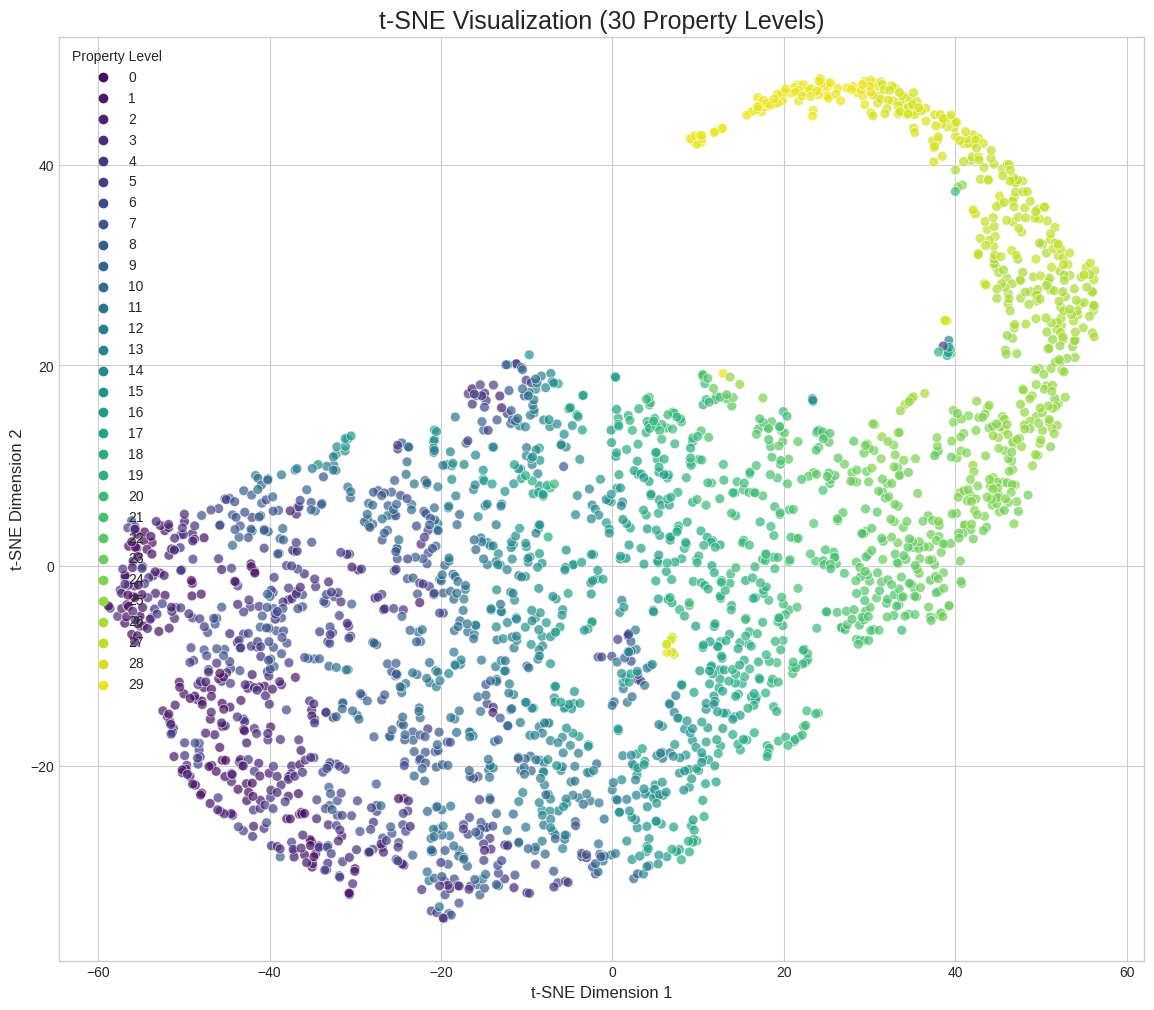

In [23]:
tsne_plot(FM_embeddings[0],FMy,30,f"{prefix}ali_tab")


Data loaded successfully.
Shape of the feature data: (2520, 256)

Starting t-SNE dimensionality reduction...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2520 samples in 0.001s...
[t-SNE] Computed neighbors for 2520 samples in 0.089s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2520
[t-SNE] Computed conditional probabilities for sample 2000 / 2520
[t-SNE] Computed conditional probabilities for sample 2520 / 2520
[t-SNE] Mean sigma: 4.883317
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.568306
[t-SNE] KL divergence after 1000 iterations: 1.128029
t-SNE calculation complete.
Generating plot...

Plot saved as '500_f4_ali_feat_tsne_30_levels.png'


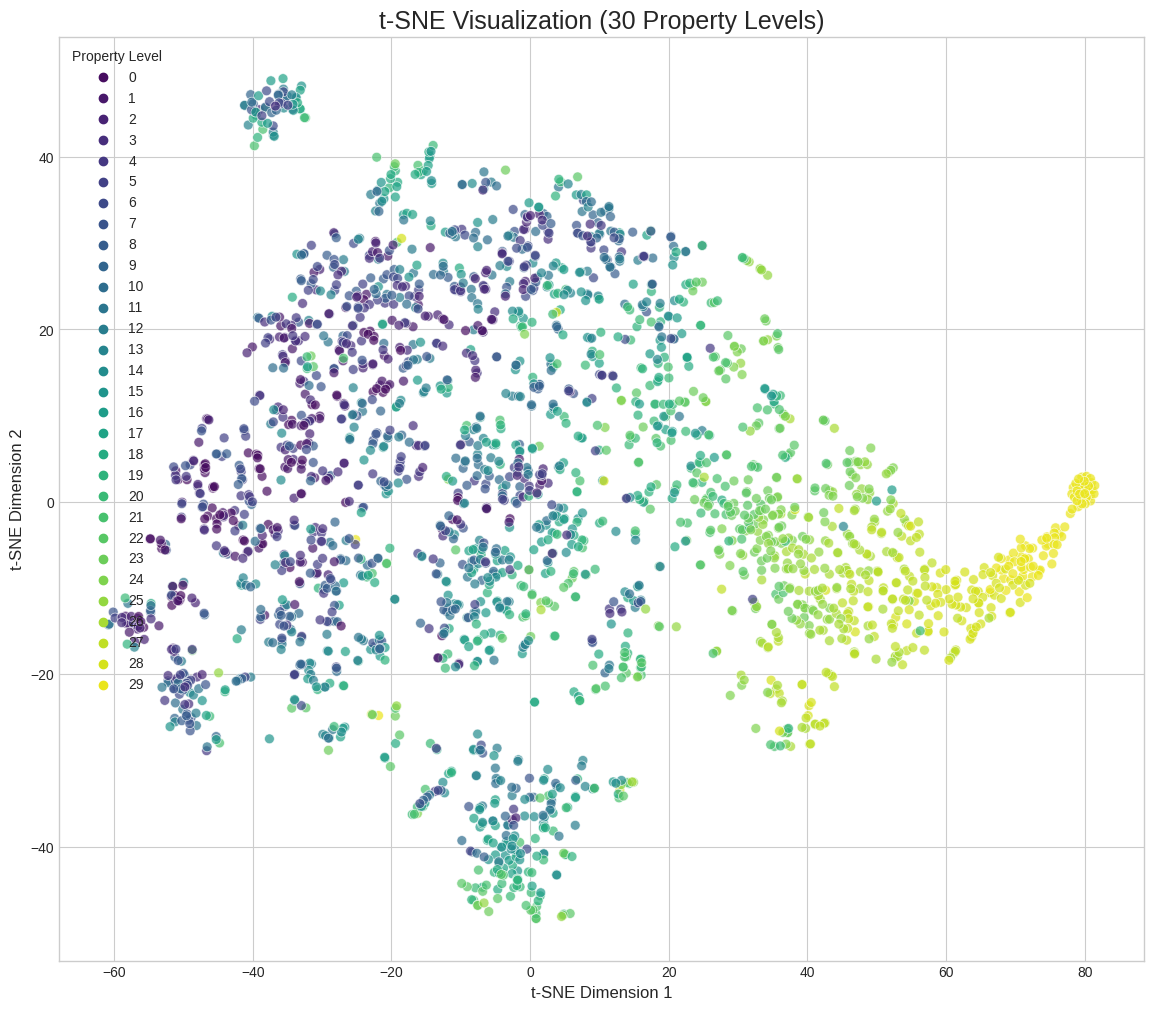

In [24]:
tsne_plot(FMX,FMy,30,f"{prefix}ali_feat")

In [27]:
TFmodel = torch.load(TF_tab)
TF_extractor = TabPFNEmbedding(tabpfn_clf=TFmodel, n_fold=0)
TF_dict = torch.load(TF_feat)  # 每个键是 jid，值是 {latent, target}         
TFX = []
TFy =[]


for k, v in TF_dict.items():
    TFX.append(v['latent'].numpy() if torch.is_tensor(v['latent']) else np.array(v['latent']))
    TFy.append(v['target'])


TFX = np.stack(TFX).astype(np.float32)
TFy = np.array(TFy).astype(np.float32)
print(TFX.shape)
print(TFy.shape)

TF_embeddings = TF_extractor.get_embeddings(
    TFX,
    TFy,
    TFX,
    data_source="train",
)

(2520, 768)
(2520,)


Data loaded successfully.
Shape of the feature data: (2520, 192)

Starting t-SNE dimensionality reduction...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2520 samples in 0.001s...
[t-SNE] Computed neighbors for 2520 samples in 0.072s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2520
[t-SNE] Computed conditional probabilities for sample 2000 / 2520
[t-SNE] Computed conditional probabilities for sample 2520 / 2520
[t-SNE] Mean sigma: 0.473811
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.169418
[t-SNE] KL divergence after 1000 iterations: 1.102185
t-SNE calculation complete.
Generating plot...

Plot saved as '500_f4_TF_tab_tsne_30_levels.png'


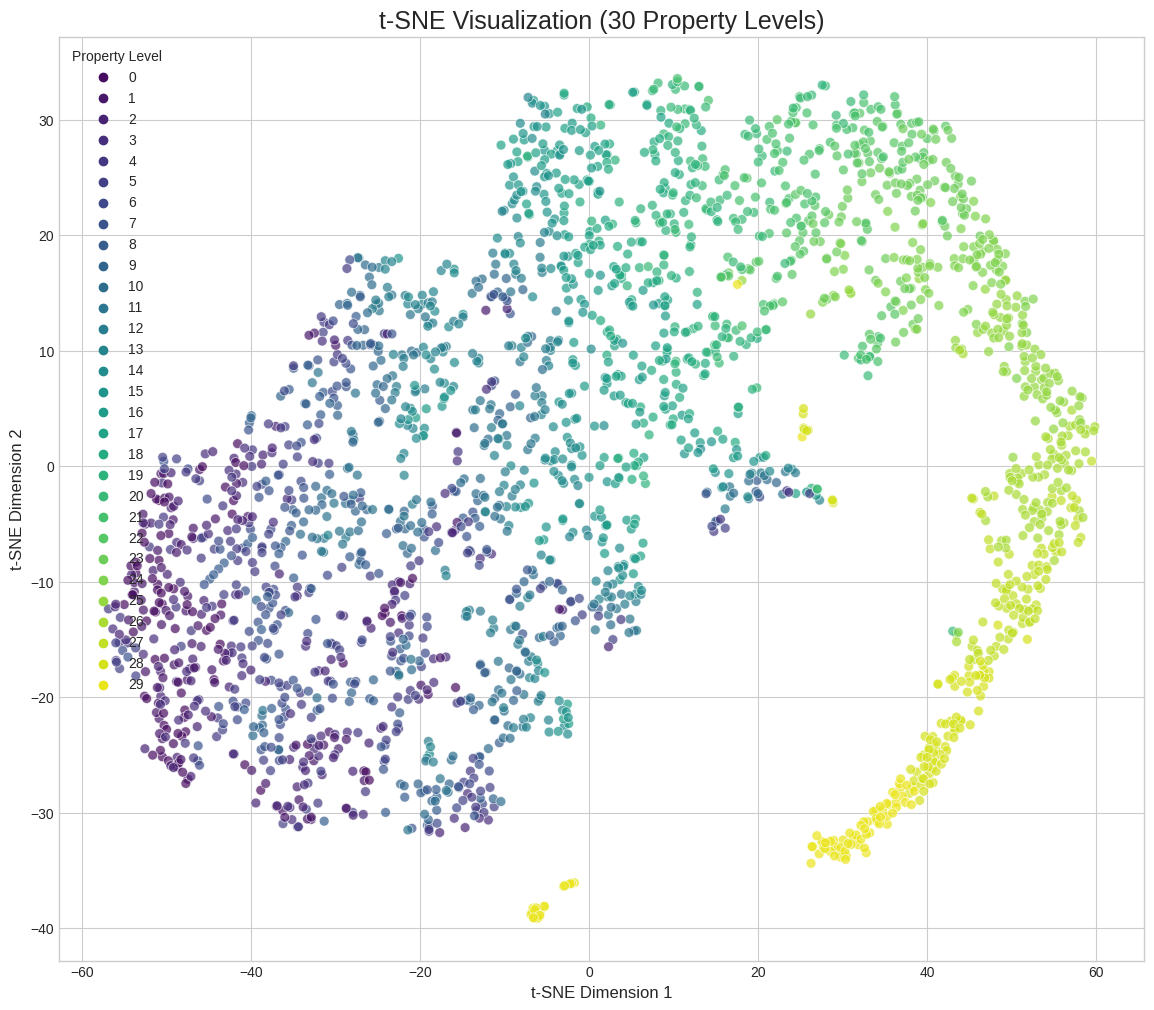

In [28]:
tsne_plot(TF_embeddings[0],TFy,30,f"{prefix}TF_tab")

Data loaded successfully.
Shape of the feature data: (2520, 768)

Starting t-SNE dimensionality reduction...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2520 samples in 0.001s...
[t-SNE] Computed neighbors for 2520 samples in 0.119s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2520
[t-SNE] Computed conditional probabilities for sample 2000 / 2520
[t-SNE] Computed conditional probabilities for sample 2520 / 2520
[t-SNE] Mean sigma: 10.330836
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.455093
[t-SNE] KL divergence after 1000 iterations: 1.012808
t-SNE calculation complete.
Generating plot...

Plot saved as '500_f4_TF_feat_tsne_30_levels.png'


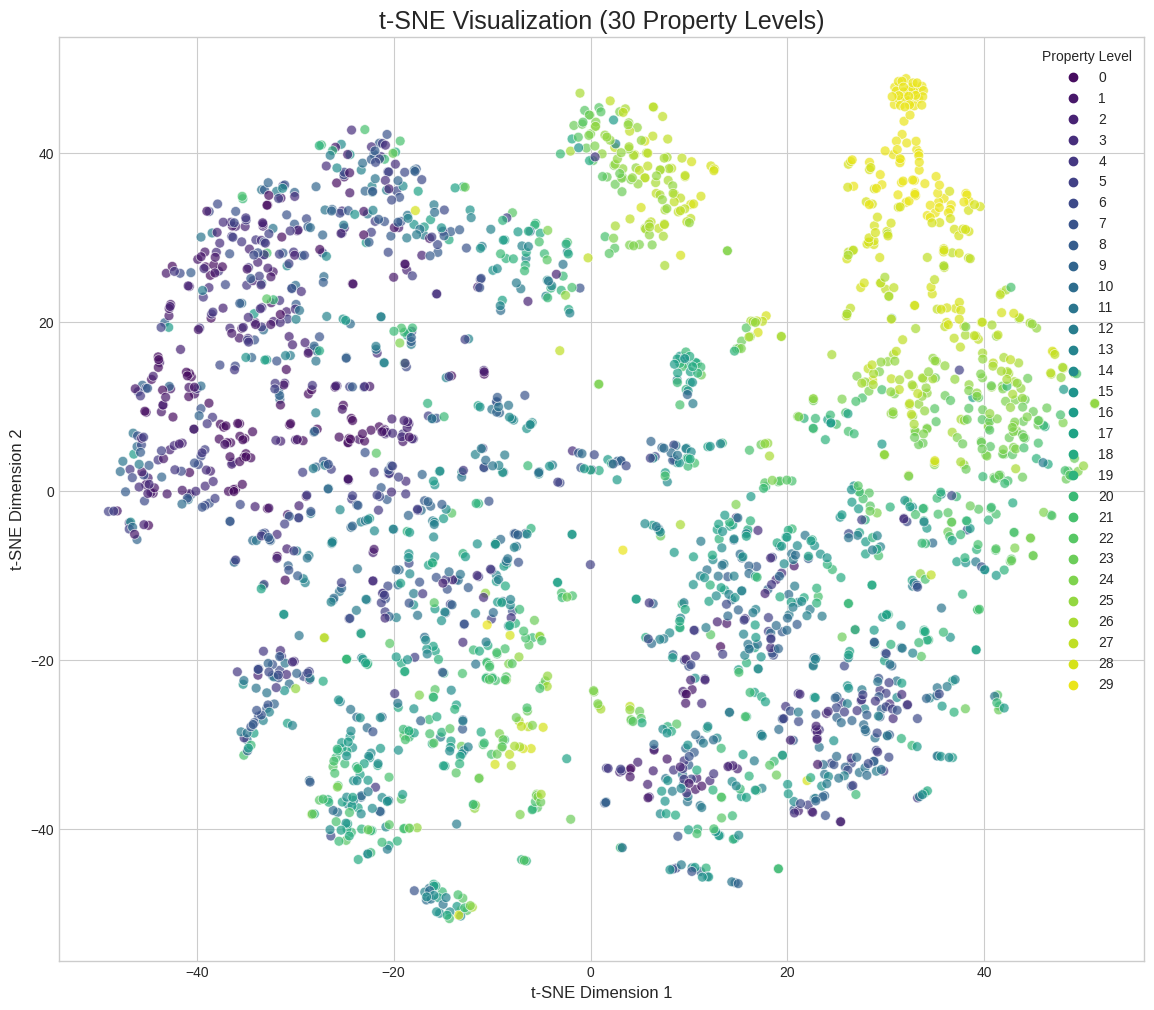

In [29]:
tsne_plot(TFX,TFy,30,f"{prefix}TF_feat")